<a href="https://colab.research.google.com/github/kirthankulkarni-bit/assip-ML-stress-monitoring/blob/main/notebooks/01_data_procesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
import os
import pickle

# mount drive
drive.mount('/content/drive')

print("copying zip file from drive to local colab storage")
!cp "/content/drive/MyDrive/ASSIP/archive.zip" "/content/archive.zip"

# unzip it locally using the linux utility
print("unzipping the local file...")
!unzip -q "/content/archive.zip" -d "/content/wesad_data"

# path to the pickle file inside the unzipped folder
data_file_path = '/content/wesad_data/WESAD/S2/S2.pkl'

print("loading subject 2 data...")
with open(data_file_path, 'rb') as file:
    subject_data = pickle.load(file, encoding='latin1')

print("keys found in the file:", subject_data.keys())

Mounted at /content/drive
copying zip file from drive to local colab storage...
unzipping the local file...
loading subject 2 data...
keys found in the file: dict_keys(['signal', 'label', 'subject'])


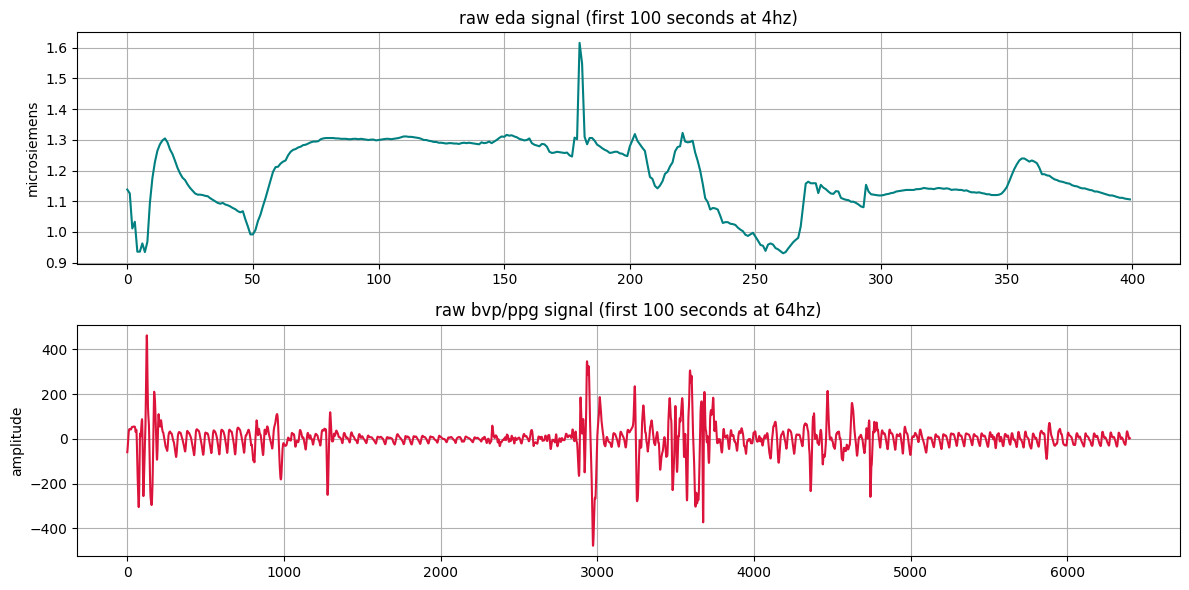

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# pulling out the raw arrays from the dictionary
eda_signal = subject_data['signal']['wrist']['EDA'].flatten()
bvp_signal = subject_data['signal']['wrist']['BVP'].flatten()

# eda is 4 hz, so 100 seconds = 400 data points
eda_slice = eda_signal[:400]

# bvp is 64 hz, so 100 seconds = 6400 data points
bvp_slice = bvp_signal[:6400]

# setting up the plots side by side or stacked
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# plotting the eda sweat response
ax1.plot(eda_slice, color='teal')
ax1.set_title('raw eda signal (first 100 seconds at 4hz)')
ax1.set_ylabel('microsiemens')
ax1.grid(True)

# plotting the bvp heart waves
ax2.plot(bvp_slice, color='crimson')
ax2.set_title('raw bvp/ppg signal (first 100 seconds at 64hz)')
ax2.set_ylabel('amplitude')
ax2.grid(True)

plt.tight_layout()
plt.show()